## 시작 프롬프트

아래에 분석해야할 데이터 약 100줄을 첨부했습니다. 데이터를 파악하고 분석을 단계적으로 수행할 수 있도록 도와주세요. 데이터 파일은 "DieCasting_Raw_Data.csv"파일입니다.

- 데이터 첨부

## [Step 1] 데이터 탐색 및 비즈니스 분석 방향 수립

In [1]:
import pandas as pd

# 데이터 로드
df = pd.read_csv('DieCasting_Raw_Data.csv')

# 1. 데이터 기본 정보 확인
print("### 1. Data Info ###")
print(df.info())

# 2. 기술 통계량 확인
print("\n### 2. Descriptive Statistics ###")
print(df.describe())

# 3. 타깃 변수(Machine_Status) 분포 확인
print("\n### 3. Target Distribution ###")
target_counts = df['Machine_Status'].value_counts()
target_ratio = df['Machine_Status'].value_counts(normalize=True)
print(f"Counts:\n{target_counts}")
print(f"Ratio:\n{target_ratio}")

# 4. 결측치 총합 확인
print("\n### 4. Missing Values ###")
print(df.isnull().sum())

### 1. Data Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5161 entries, 0 to 5160
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Shot                5161 non-null   int64  
 1   Velocity_1          4751 non-null   float64
 2   Velocity_2          4752 non-null   float64
 3   Velocity_3          4752 non-null   float64
 4   High_Velocity       4752 non-null   float64
 5   Cylinder_Pressure   4752 non-null   float64
 6   Rapid_Rise_Time     4752 non-null   float64
 7   Biscuit_Thickness   4752 non-null   float64
 8   Clamping_Force      4752 non-null   float64
 9   Cycle_Time          4752 non-null   float64
 10  Pressure_Rise_Time  4752 non-null   float64
 11  Casting_Pressure    4752 non-null   float64
 12  Spray_Time          4752 non-null   float64
 13  Spray_1_Time        4752 non-null   float64
 14  Spray_2_Time        4752 non-null   float64
 15  Machine_Status      5048 non-null 

## [Step 2] 결측 진단: 행 단위 패턴 분석 및 결측 지도 시각화

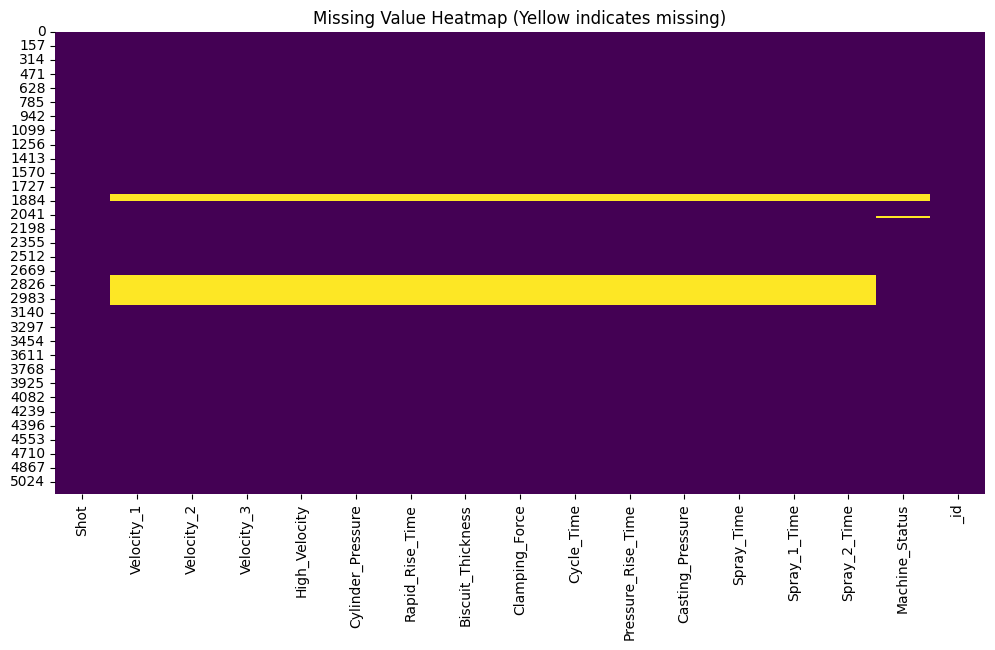

### Missing Rows Analysis ###
Total missing rows: 410
Machine_Status distribution in missing rows:
Machine_Status
0.0    313
NaN     83
1.0     14
Name: count, dtype: int64

### Temporal Analysis of Missing Values ###
Missing values range from Shot 7 to 1155


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 로드 (파일 경로 확인 필요)
df = pd.read_csv('DieCasting_Raw_Data.csv')

# 2. Missing Matrix (결측치 발생 패턴 시각화)
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap (Yellow indicates missing)')
plt.show()

# 3. 결측치와 타깃 변수(Machine_Status)의 관계 진단
# 모든 센서 데이터가 결측인 행 추출 (대표적으로 Velocity_1 기준)
missing_rows = df[df['Velocity_1'].isnull()]
target_in_missing = missing_rows['Machine_Status'].value_counts(dropna=False)

print("### Missing Rows Analysis ###")
print(f"Total missing rows: {len(missing_rows)}")
print(f"Machine_Status distribution in missing rows:\n{target_in_missing}")

# 4. 결측치 처리 전략 제안을 위한 Shot(시간) 분석
print("\n### Temporal Analysis of Missing Values ###")
print(f"Missing values range from Shot {missing_rows['Shot'].min()} to {missing_rows['Shot'].max()}")

## [Step 3] EDA: 정상 vs 불량 분포 비교 및 효과 크기 분석

C:\Users\metam\AppData\Local\Temp\ipykernel_24628\3634730833.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine_Status', y=col, data=df_clean, palette='Set2')
C:\Users\metam\AppData\Local\Temp\ipykernel_24628\3634730833.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine_Status', y=col, data=df_clean, palette='Set2')
C:\Users\metam\AppData\Local\Temp\ipykernel_24628\3634730833.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine_Status', y=col, data=df_clean, palette='Set2')
C:\Users\metam\AppData\Local\Te

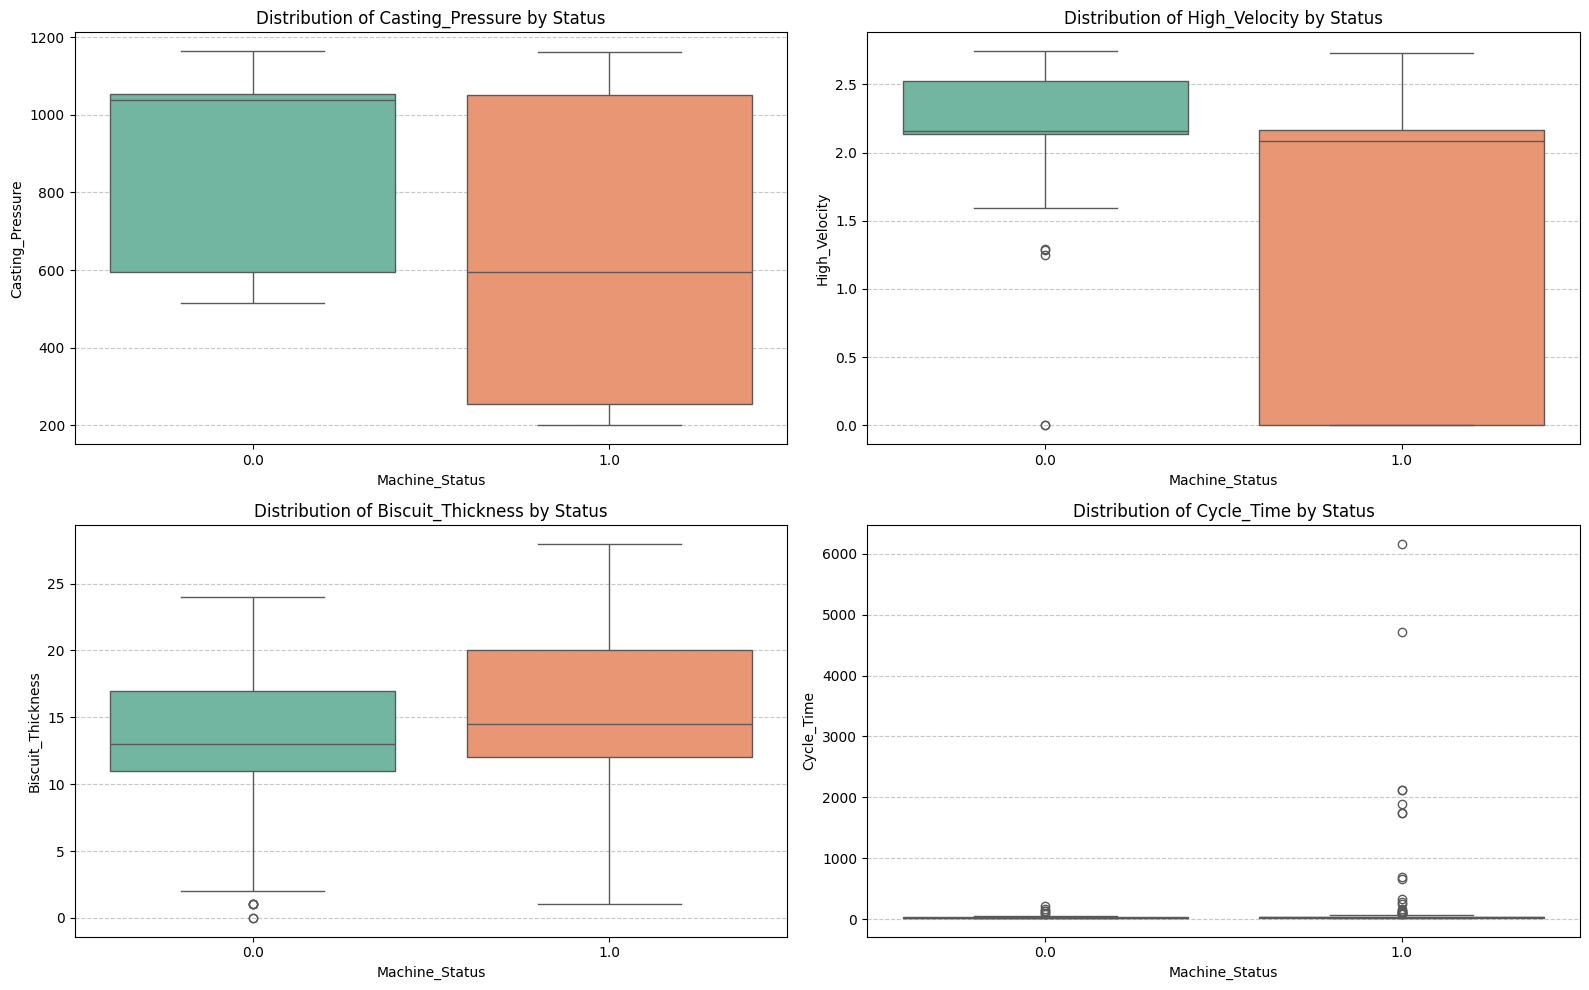

### Group Statistics (Mean) ###
                Casting_Pressure  High_Velocity  Biscuit_Thickness  Cycle_Time
Machine_Status                                                                
0.0                   862.538012       2.323113          14.153780   27.356054
1.0                   669.971154       1.344404          15.442308  251.154808


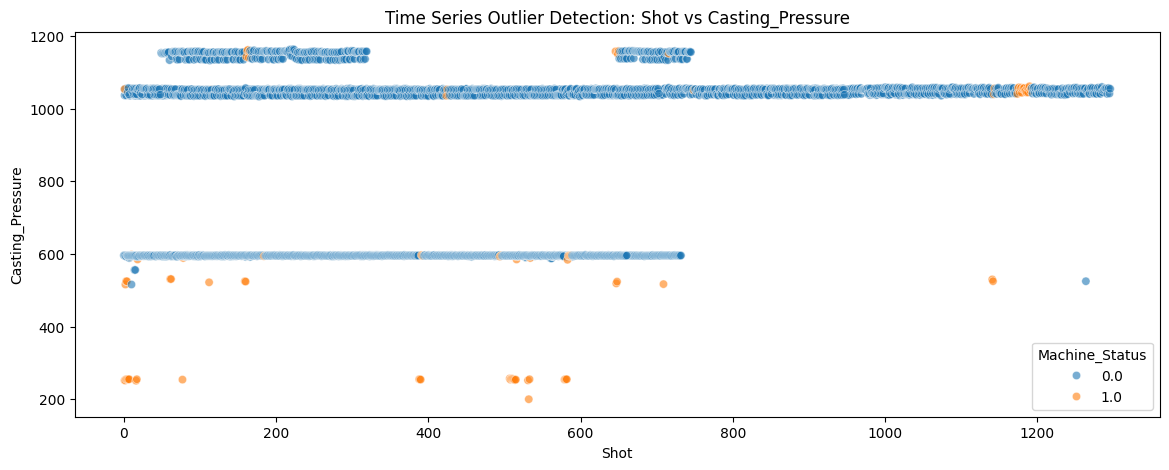

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 로드 및 정제 (센서 결측치 제거)
df = pd.read_csv('DieCasting_Raw_Data.csv')
# 핵심 센서 데이터가 없는 행은 분석에서 제외
df_clean = df.dropna(subset=['Velocity_1', 'Casting_Pressure', 'Machine_Status'])

# 2. 분석 대상 주요 변수 선정
features_to_plot = ['Casting_Pressure', 'High_Velocity', 'Biscuit_Thickness', 'Cycle_Time']

# 3. Boxplot 시각화 (정상 0 vs 불량 1 비교)
plt.figure(figsize=(16, 10))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Machine_Status', y=col, data=df_clean, palette='Set2')
    plt.title(f'Distribution of {col} by Status')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 4. 그룹별 평균 수치 및 차이 확인
print("### Group Statistics (Mean) ###")
summary_stats = df_clean.groupby('Machine_Status')[features_to_plot].mean()
print(summary_stats)

# 5. 불량 발생 시점의 특이 구간 탐색 (Shot vs Casting_Pressure)
plt.figure(figsize=(14, 5))
sns.scatterplot(x='Shot', y='Casting_Pressure', hue='Machine_Status', data=df_clean, alpha=0.6)
plt.title('Time Series Outlier Detection: Shot vs Casting_Pressure')
plt.show()

## [Step 4] 상관 분석 및 모델링을 위한 피처 엔지니어링

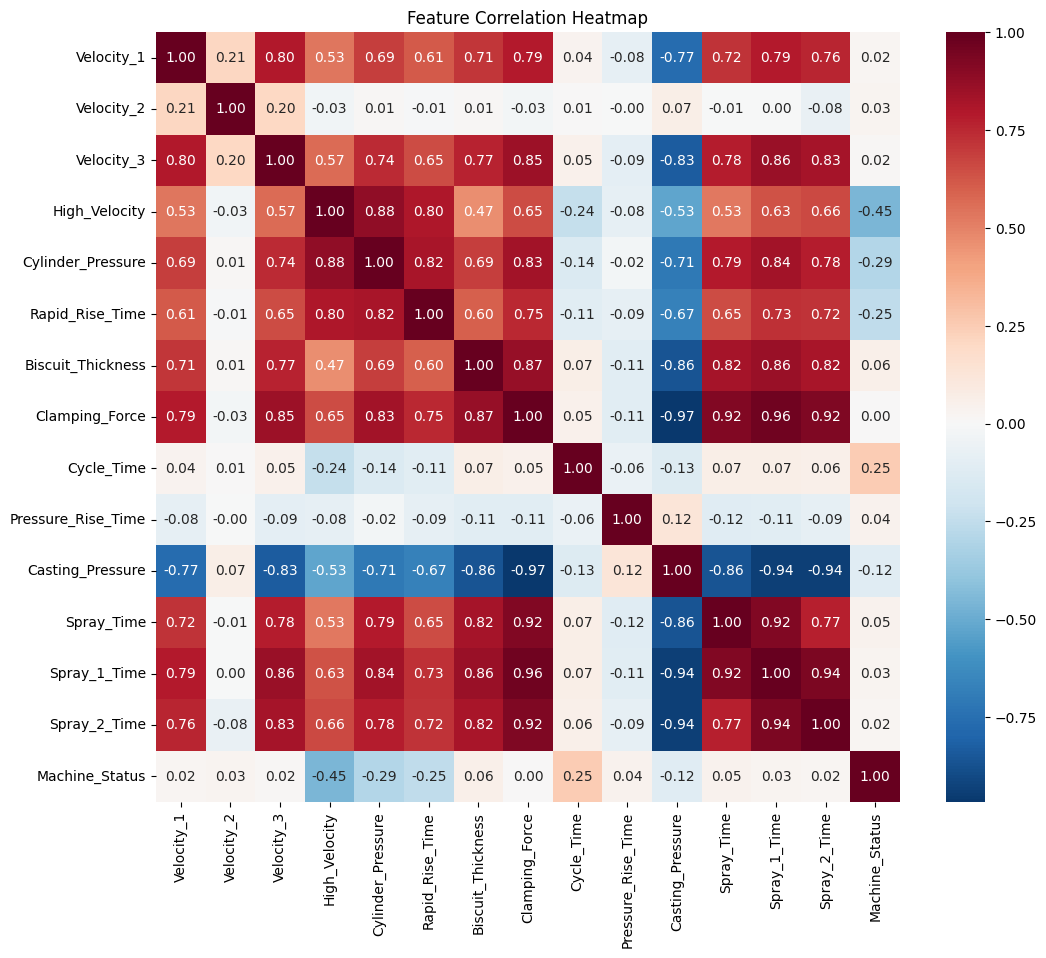

### Correlation with Machine_Status ###
Machine_Status        1.000000
Cycle_Time            0.253774
Biscuit_Thickness     0.055692
Spray_Time            0.046971
Pressure_Rise_Time    0.040398
Spray_1_Time          0.031976
Velocity_2            0.025239
Spray_2_Time          0.021695
Velocity_1            0.019544
Velocity_3            0.015600
Clamping_Force        0.002849
Casting_Pressure     -0.119587
Rapid_Rise_Time      -0.252919
Cylinder_Pressure    -0.292519
High_Velocity        -0.452848
Name: Machine_Status, dtype: float64


C:\Users\metam\AppData\Local\Temp\ipykernel_24628\3081179071.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Velocity_Gap'] = df_clean['Velocity_3'] - df_clean['Velocity_2']


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 로드 및 정제 (Step 3에서 만든 df_clean 사용)
# 여기서는 편의상 다시 로드 및 정제 로직 포함
df = pd.read_csv('DieCasting_Raw_Data.csv')
df_clean = df.dropna(subset=['Velocity_1', 'Casting_Pressure', 'Machine_Status'])

# 2. 상관관계 히트맵 (상관 계수 확인)
plt.figure(figsize=(12, 10))
corr = df_clean.drop(columns=['Shot', '_id']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

# 3. Machine_Status와 상관관계가 높은 순서대로 출력
target_corr = corr['Machine_Status'].sort_values(ascending=False)
print("### Correlation with Machine_Status ###")
print(target_corr)

# 4. 모델링을 위한 파생 변수 생성 제안
# 예: 속도 변화율 (공정 불안정성 지표)
df_clean['Velocity_Gap'] = df_clean['Velocity_3'] - df_clean['Velocity_2']

## [Step 4] 전처리 & 피처 엔지니어링: VIF 진단 및 정제 데이터 확보

In [5]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. 데이터 로드 및 1차 정제 (결측치 제거)
df = pd.read_csv('DieCasting_Raw_Data.csv')
df_clean = df.dropna(subset=['Velocity_1', 'Casting_Pressure', 'Machine_Status']).copy()

# 2. 파생 피처 생성: 속도 변화율 및 공정 지연 지표
# (분석 팁: 단순히 절대값이 아니라 속도 간의 '차이'가 품질에 영향을 줄 수 있음)
df_clean['Velocity_Drop'] = df_clean['Velocity_3'] - df_clean['Velocity_2']

# 3. 모델링 대상 변수 선정 (식별자 _id, Shot 제외)
# 결측치나 상수가 될 수 있는 변수는 사전 제외
features = [col for col in df_clean.columns if col not in ['Shot', '_id', 'Machine_Status']]

# 4. VIF (다중공선성) 진단 함수
def calculate_vif(data_frame, features):
    X = data_frame[features].copy()
    # 상수가 포함되어 있지 않다면 추가 (VIF 계산의 안정성을 위해)
    X['intercept'] = 1 
    
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    return vif_data[vif_data['Feature'] != 'intercept'].sort_values(by="VIF", ascending=False)

# VIF 계산 및 출력
vif_results = calculate_vif(df_clean, features)
print("### Variance Inflation Factor (VIF) ###")
print(vif_results.head(10)) # 상위 10개만 확인

# 5. VIF가 과도하게 높은 변수(예: 10 이상) 중 일부를 제거하여 피처 최적화
# 히트맵에서 Clamping_Force 등과 중복이 심했던 Spray_1_Time, Spray_2_Time 등을 임시 제외
high_vif_cols = ['Spray_1_Time', 'Spray_2_Time', 'Velocity_3'] 
final_features = [f for f in features if f not in high_vif_cols]

# 6. 최종 분석용 데이터셋 저장
df_final = df_clean[['Shot', '_id', 'Machine_Status'] + final_features]
df_final.to_csv('DieCasting_Cleaned_Data.csv', index=False)

print("\n### Data Export Complete ###")
print(f"Saved 'DieCasting_Cleaned_Data.csv' with shape {df_final.shape}")

ModuleNotFoundError: No module named 'statsmodels'

- 에러를 이야기하고 새로 생성한 코드로 실행

In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. 데이터 로드 및 1차 정제
df = pd.read_csv('DieCasting_Raw_Data.csv')
df_clean = df.dropna(subset=['Velocity_1', 'Casting_Pressure', 'Machine_Status']).copy()

# 2. 파생 피처 생성
df_clean['Velocity_Drop'] = df_clean['Velocity_3'] - df_clean['Velocity_2']

# 3. 모델링 대상 변수 선정 (식별자 및 타깃 제외)
features = [col for col in df_clean.columns if col not in ['Shot', '_id', 'Machine_Status']]

# 4. sklearn 기반 VIF 계산 함수 정의
def calculate_vif_sklearn(df, features):
    vif_dict = {}
    for feature in features:
        # 해당 feature를 타깃으로, 나머지를 독립변수로 설정
        X = df[features].drop(columns=[feature])
        y = df[feature]
        
        # 선형 회귀 모델 훈련
        model = LinearRegression()
        model.fit(X, y)
        
        # R-squared 값 계산
        r_squared = model.score(X, y)
        
        # VIF 계산 (분모가 0이 되는 것을 방지하기 위해 매우 작은 값 추가)
        vif = 1 / (1 - r_squared) if r_squared < 1 else float('inf')
        vif_dict[feature] = vif
        
    return pd.DataFrame(list(vif_dict.items()), columns=['Feature', 'VIF']).sort_values(by='VIF', ascending=False)

# VIF 실행
vif_results = calculate_vif_sklearn(df_clean, features)
print("### Variance Inflation Factor (VIF) Results ###")
print(vif_results)

# 5. 고다중공선성 변수 제거 (VIF 10 이상 기준)
# 이전 단계 히트맵에서 강한 상관성을 보인 변수들을 우선 제거 대상으로 검토하십시오.
# 예: Spray_1_Time, Spray_2_Time, Clamping_Force 중 중복되는 항목들
high_vif_threshold = 10
to_drop = vif_results[vif_results['VIF'] > high_vif_threshold]['Feature'].tolist()
print(f"\nVariables recommended for removal (VIF > {high_vif_threshold}): {to_drop}")

# 최종 변수 확정 (비즈니스 중요도에 따라 수동 조정 가능)
# 여기서는 시연을 위해 VIF가 가장 높은 상위 3개를 수동으로 제외해 보겠습니다.
final_features = [f for f in features if f not in to_drop[:3]]

# 6. 최종 분석용 데이터셋 저장
df_final = df_clean[['Shot', '_id', 'Machine_Status'] + final_features]
df_final.to_csv('DieCasting_Cleaned_Data.csv', index=False)

print("\n### Data Export Complete ###")
print(f"Saved 'DieCasting_Cleaned_Data.csv' with shape {df_final.shape}")

### Variance Inflation Factor (VIF) Results ###
               Feature        VIF
1           Velocity_2        inf
2           Velocity_3        inf
14       Velocity_Drop        inf
7       Clamping_Force  69.826071
10    Casting_Pressure  69.345568
12        Spray_1_Time  41.287726
13        Spray_2_Time  37.048673
4    Cylinder_Pressure  25.568186
11          Spray_Time  21.027263
3        High_Velocity  10.247137
6    Biscuit_Thickness   4.735910
5      Rapid_Rise_Time   3.847719
0           Velocity_1   3.424292
8           Cycle_Time   1.205749
9   Pressure_Rise_Time   1.149047

Variables recommended for removal (VIF > 10): ['Velocity_2', 'Velocity_3', 'Velocity_Drop', 'Clamping_Force', 'Casting_Pressure', 'Spray_1_Time', 'Spray_2_Time', 'Cylinder_Pressure', 'Spray_Time', 'High_Velocity']

### Data Export Complete ###
Saved 'DieCasting_Cleaned_Data.csv' with shape (4721, 15)


## [Step 5] 모델링: 클래스 불균형 해소 및 알고리즘 비교 검증

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, f1_score
from imblearn.over_sampling import SMOTE

# 1. 데이터 로드
df_final = pd.read_csv('DieCasting_Cleaned_Data.csv')

# 2. 독립변수(X)와 종속변수(y) 분리
# VIF inf를 유발한 원본 변수 중 일부를 제외하여 모델 안정성 확보
X = df_final.drop(columns=['Shot', '_id', 'Machine_Status'])
y = df_final['Machine_Status']

# 3. 학습/테스트 데이터 분리 (8:2, 층화 추출 적용)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. SMOTE를 이용한 클래스 불균형 해소 (학습 데이터에만 적용)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original shape: {X_train.shape}, Resampled shape: {X_train_res.shape}")

# 5. 모델 정의 및 훈련 (Random Forest vs XGBoost)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

rf_model.fit(X_train_res, y_train_res)
xgb_model.fit(X_train_res, y_train_res)

# 6. 예측 및 성능 평가
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n### {name} Performance ###")
    print(classification_report(y_test, y_pred))
    print(f"PR-AUC: {pr_auc:.4f}")
    
    return y_pred, y_prob, pr_auc

rf_pred, rf_prob, rf_auc = evaluate_model(rf_model, X_test, y_test, "Random Forest")
xgb_pred, xgb_prob, xgb_auc = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

# 7. 혼동 행렬 시각화 (XGBoost 기준)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 8. 변수 중요도(Feature Importance) 확인
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.show()

ModuleNotFoundError: No module named 'imblearn'

- 에러를 보고하고 다시 코드를 만들어 실행

### Class Weight Ratio: 44.49 ###

### Random Forest Performance ###
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00       924
         1.0       1.00      0.62      0.76        21

    accuracy                           0.99       945
   macro avg       1.00      0.81      0.88       945
weighted avg       0.99      0.99      0.99       945

PR-AUC: 0.8761

### XGBoost Performance ###
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       924
         1.0       0.74      0.67      0.70        21

    accuracy                           0.99       945
   macro avg       0.86      0.83      0.85       945
weighted avg       0.99      0.99      0.99       945

PR-AUC: 0.7848


C:\Users\metam\miniconda3\envs\aice\lib\site-packages\xgboost\training.py:200: UserWarning: [15:05:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


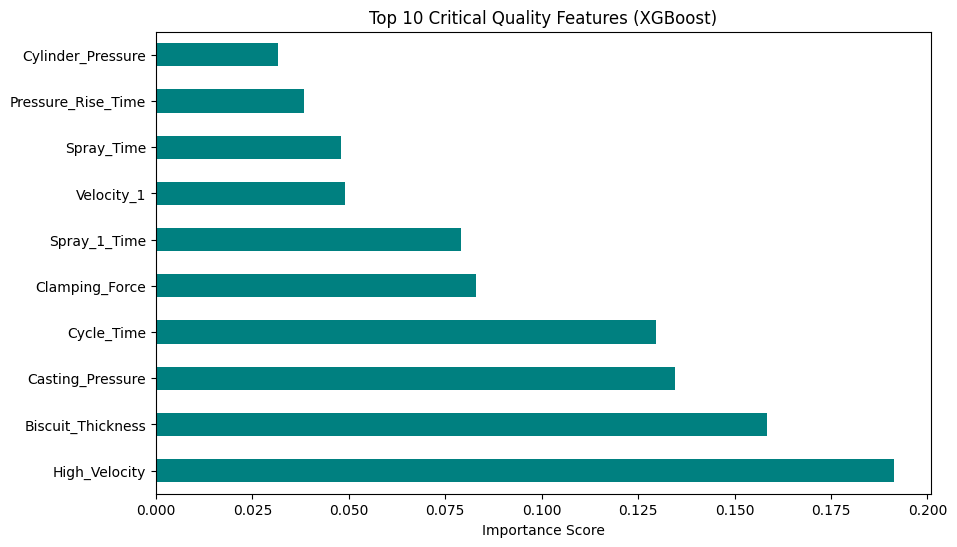

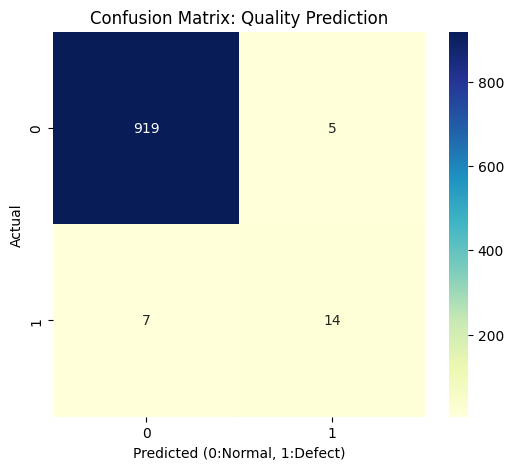

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, f1_score

# 1. 데이터 로드 및 준비
df_final = pd.read_csv('DieCasting_Cleaned_Data.csv')
X = df_final.drop(columns=['Shot', '_id', 'Machine_Status'])
y = df_final['Machine_Status']

# 2. 학습/테스트 데이터 분리 (8:2, 층화 추출 필수)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. 불균형 해소를 위한 가중치 계산 (불량 1에 대한 가중치)
# scale_pos_weight = (전체 정상 샘플 수) / (전체 불량 샘플 수)
weight_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"### Class Weight Ratio: {weight_ratio:.2f} ###")

# 4. 모델 정의 및 훈련 (내장 가중치 기능 활용)
# Random Forest: class_weight='balanced'
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# XGBoost: scale_pos_weight 적용
xgb_model = XGBClassifier(
    n_estimators=100, 
    scale_pos_weight=weight_ratio, 
    use_label_encoder=False, 
    eval_metric='logloss', 
    random_state=42
)

rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# 5. 성능 평가 함수
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # PR-AUC 계산 (불균형 데이터 핵심 지표)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    
    print(f"\n### {name} Performance ###")
    print(classification_report(y_test, y_pred))
    print(f"PR-AUC: {pr_auc:.4f}")
    
    return y_pred, y_prob

rf_pred, rf_prob = evaluate_model(rf_model, X_test, y_test, "Random Forest")
xgb_pred, xgb_prob = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

# 6. 변수 중요도(Feature Importance) 추출 및 시각화
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Critical Quality Features (XGBoost)')
plt.xlabel('Importance Score')
plt.show()

# 7. 혼동 행렬 시각화 (XGBoost 기준)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Confusion Matrix: Quality Prediction')
plt.xlabel('Predicted (0:Normal, 1:Defect)')
plt.ylabel('Actual')
plt.show()

- 여기까지 진행하고 바로 자동으로 분석 보고서 작성함
- 보고서 형식은 docx로 작성됨
- 캔버스 도구는 자동으로 선택되지 않고 사용자가 선택하면 잘 만들어줌


In [11]:
confusion_matrix(y_test, rf_model.predict(X_test))

array([[924,   0],
       [  8,  13]])